# Test d1s1 customized to be non-parametric and with spv of the scaling laws at ns1

In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from fgbuster.observation_helpers import *
from fgbuster.separation_recipes import basic_comp_sep
from fgbuster.component_model import CMB, Dust, Synchrotron

from micmac import fgs_freq_maps_from_customized_model_nonparam

In [2]:
nside_map = 64
nside_spv_map = 1
nside_spv_patches = 1
noise_seed = 42
instr_name = 'LiteBIRD'
mask_path = '/Users/arizzieri/APC/PhD/cmb_work/common/masks/HFI_Mask_GalPlane-apo0_2048_R2.00.fits'

In [3]:
instrument = get_instrument(instr_name)

In [4]:
models = ['s1', 'd7']
models_unified = ''.join(models)

In [5]:
# get input freq maps customized with less spv of SEDs
freq_maps_fgs_denoised, mixing_mat_fgs = fgs_freq_maps_from_customized_model_nonparam(nside_map, nside_spv_map, instrument, fgs_models=models, idx_ref_freq=6)
np.random.seed(noise_seed)
noise_map = get_noise_realization(nside_map, instrument)[:, 1:, :]
freq_maps = freq_maps_fgs_denoised + noise_map

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [6]:
# add mask
mask_ = hp.read_map(mask_path, field=2, dtype=np.float64)
mask = hp.ud_grade(mask_, nside_out=nside_map)
freq_maps[..., mask == 0] = hp.UNSEEN

### Difference maps d1s1 and customized d1s1

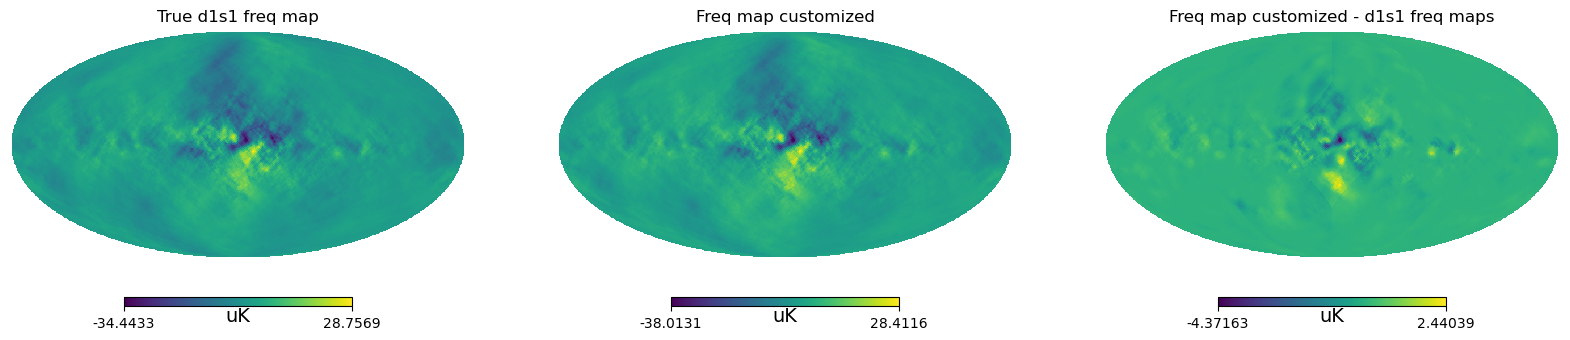

In [7]:
freq_maps_d1s1 = get_observation(instrument, models_unified, noise=False, nside=nside_map)[:, 1:, :]
freq_map_plot_idx = 0
stok_idx = 1

fig, ax = plt.subplots(1, 3, figsize=[20., 10.])
plt.axes(ax[0])
hp.mollview(freq_maps_d1s1[freq_map_plot_idx, stok_idx, :], hold=True, title='True d1s1 freq map', unit='uK')
plt.axes(ax[1])
hp.mollview(freq_maps_fgs_denoised[freq_map_plot_idx, stok_idx, :], hold=True, title='Freq map customized', unit='uK')
plt.axes(ax[2])
hp.mollview(freq_maps_fgs_denoised[freq_map_plot_idx, stok_idx, :]-freq_maps_d1s1[freq_map_plot_idx, stok_idx, :], hold=True, title='Freq map customized - d1s1 freq maps', unit='uK')
plt.show()

### Checking the scaling laws of the customized models

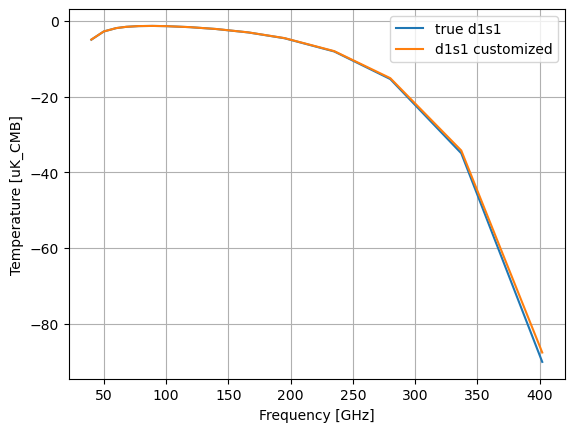

In [8]:
from fgbuster.component_model import K_RJ2K_CMB

pix_idx = 2256

plt.plot(instrument.frequency, freq_maps_d1s1[:, stok_idx, pix_idx], label='true d1s1')
plt.plot(instrument.frequency, freq_maps_fgs_denoised[:, stok_idx, pix_idx], label='d1s1 customized')
plt.ylabel('Temperature [uK_CMB]')
plt.xlabel('Frequency [GHz]')
plt.legend()
plt.grid()

### Parametric comp sep

In [9]:
stokes_lab = ['Q', 'U']
components = [CMB(), Dust(nu0=100.), Synchrotron(nu0=100.)]
comp_lab = ['res', 'dust', 'sync']

In [10]:
result = basic_comp_sep(components, instrument, freq_maps_fgs_denoised, nside=1)

(array([ 1.54, 20.  , -3.  ]),)
(array([ 1.54, 20.  , -3.  ]),)
(array([ 1.54, 20.  , -3.  ]),)
(array([ 1.54, 20.  , -3.  ]),)
(array([ 1.54, 20.  , -3.  ]),)
(array([ 1.54, 20.  , -3.  ]),)
(array([ 1.54, 20.  , -3.  ]),)
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated


<lambdifygenerated-9>:2: RuntimeWarning: overflow encountered in power
  return 58174.79101282193*(0.01*nu)**beta_pl*numpy.expm1(0.01760867023799751*nu)**2*exp(-0.01760867023799751*nu)/(nu**2*numpy.expm1(1.760867023799751)**2)
<lambdifygenerated-10>:2: RuntimeWarning: overflow encountered in power
  return 58174.79101282193*(0.01*nu)**beta_pl*numpy.expm1(0.01760867023799751*nu)**2*exp(-0.01760867023799751*nu)*log(0.01*nu)/(nu**2*numpy.expm1(1.760867023799751)**2)
<lambdifygenerated-2>:2: RuntimeWarning: overflow encountered in power
  return 58174.79101282193*(0.01*nu)**(beta_d + 1)*(exp(4.79924307336622/temp) - 1)*numpy.expm1(0.01760867023799751*nu)**2*exp(-0.01760867023799751*nu)/(nu**2*(exp(0.0479924307336622*nu/temp) - 1)*numpy.expm1(1.760867023799751)**2)
<lambdifygenerated-2>:2: RuntimeWarning: overflow encountered in multiply
  return 58174.79101282193*(0.01*nu)**(beta_d + 1)*(exp(4.79924307336622/temp) - 1)*numpy.expm1(0.01760867023799751*nu)**2*exp(-0.01760867023799751*nu)/(nu

SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> l

<lambdifygenerated-9>:2: RuntimeWarning: overflow encountered in power
  return 58174.79101282193*(0.01*nu)**beta_pl*numpy.expm1(0.01760867023799751*nu)**2*exp(-0.01760867023799751*nu)/(nu**2*numpy.expm1(1.760867023799751)**2)
<lambdifygenerated-10>:2: RuntimeWarning: overflow encountered in power
  return 58174.79101282193*(0.01*nu)**beta_pl*numpy.expm1(0.01760867023799751*nu)**2*exp(-0.01760867023799751*nu)*log(0.01*nu)/(nu**2*numpy.expm1(1.760867023799751)**2)
<lambdifygenerated-9>:2: RuntimeWarning: overflow encountered in multiply
  return 58174.79101282193*(0.01*nu)**beta_pl*numpy.expm1(0.01760867023799751*nu)**2*exp(-0.01760867023799751*nu)/(nu**2*numpy.expm1(1.760867023799751)**2)
<lambdifygenerated-10>:2: RuntimeWarning: overflow encountered in multiply
  return 58174.79101282193*(0.01*nu)**beta_pl*numpy.expm1(0.01760867023799751*nu)**2*exp(-0.01760867023799751*nu)*log(0.01*nu)/(nu**2*numpy.expm1(1.760867023799751)**2)
<lambdifygenerated-2>:2: RuntimeWarning: overflow encounte

(array([ 1.54, 20.  , -3.  ]),)
(array([ 1.54, 20.  , -3.  ]),)
(array([ 1.54, 20.  , -3.  ]),)
(array([ 1.54, 20.  , -3.  ]),)


In [11]:
# explore the results
result.x

array([[ 1.54685289e+00,  1.55190621e+00,  1.54445174e+00,
         1.54494719e+00,  1.54496240e+00,  1.54958769e+00,
         2.80461125e+04,  1.54646441e+00,  1.54462770e+00,
         1.55054448e+00,  1.54555506e+00,  1.54580092e+00],
       [ 1.47589807e+01,  1.44738572e+01,  1.40171917e+01,
         1.45975594e+01,  1.39230046e+01,  1.28619468e+01,
        -8.25624311e+05,  1.29017785e+01,  1.42717669e+01,
         1.42129689e+01,  1.45758434e+01,  1.45622241e+01],
       [-3.01351902e+00, -3.02597838e+00, -2.97032364e+00,
        -3.04686015e+00, -3.07445171e+00, -3.03584312e+00,
         5.41959830e+05, -3.05892160e+00, -3.01238053e+00,
        -2.99702050e+00, -2.98180151e+00, -3.04385538e+00]])

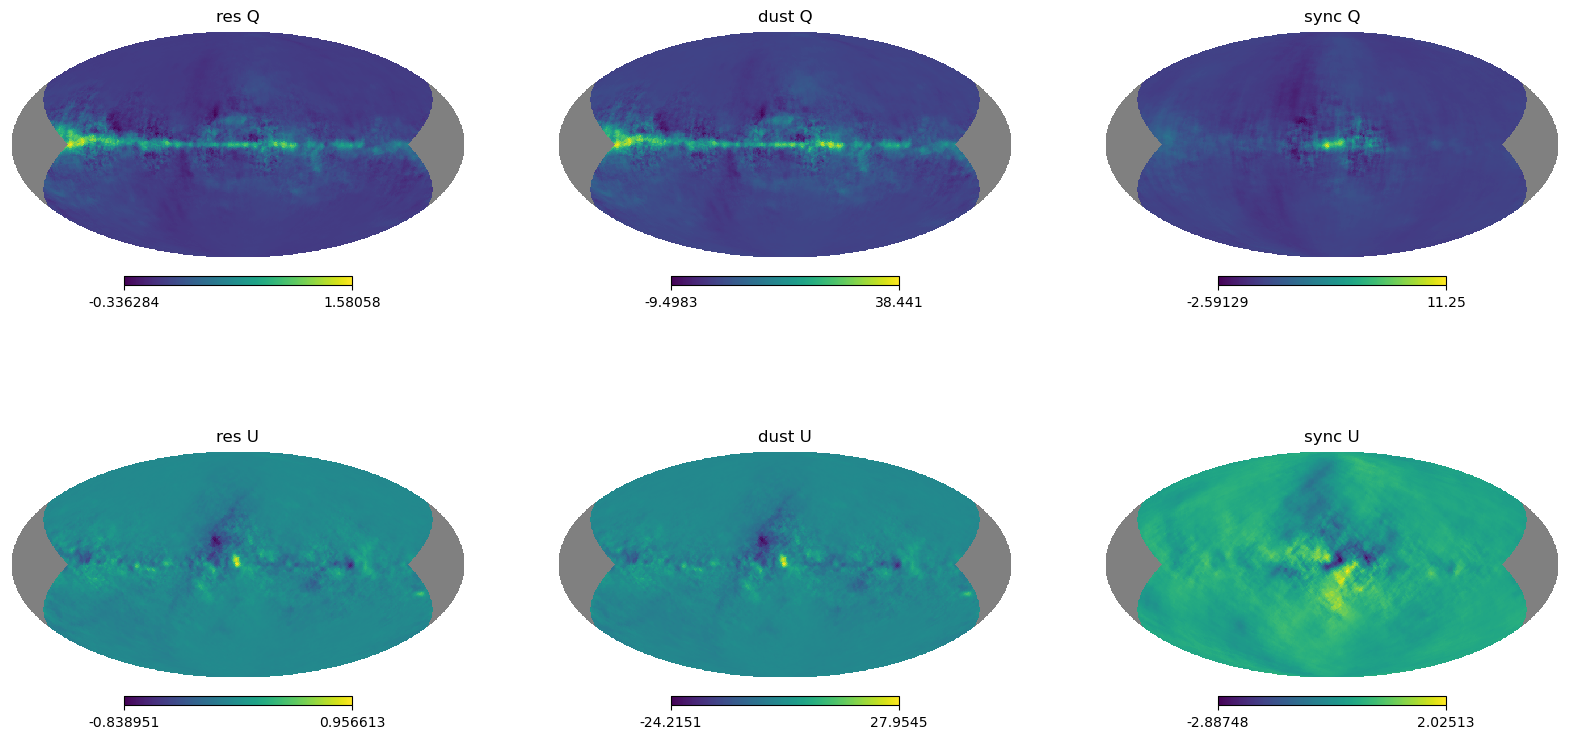

In [12]:
fig, ax = plt.subplots(2, 3, figsize=[20., 10.])
for i in range(np.shape(result.s)[0]):
    for j in range(np.shape(result.s)[1]):
        lab = comp_lab[i] + ' ' + stokes_lab[j]
        plt.axes(ax[j][i])
        hp.mollview(result.s[i, j], hold=True, title=lab)
plt.show()